# RL поверх топ-5 часовых альф: лонг / шорт / холд

**Вопрос эксперимента:** на дневках RL-таймер проиграл «всегда лонгу» — там было всего
~1200 обучающих баров. На 1h обучающих баров **~26 000 (в ~20 раз больше)**. Хватит ли
этого, чтобы агент научился таймить портфель из топ-5 часовых альф?

**Два агента (оба платят 10 bp за единицу переключения позиции):**
- **Агент A — табличный Q-learning**, как в дневном эксперименте, но состояние богаче:
  216 состояний вместо 36 (моментум портфеля, режим волы, просадка, моментум BTC,
  знак funding, торговая сессия).
- **Агент B — model-based RL с ~25 непрерывными фичами.** Здесь важная честность:
  награда `a·r(t+1)` контрфактична (рынок не реагирует на наши действия), поэтому
  «настоящий» RL математически схлопывается в задачу *прогноза следующего бара* +
  оптимальную политику переключения с учётом издержек. Агент B делает это явно:
  градиентный бустинг учит E[r(t+1)|фичи], политика переключается только когда
  ожидаемый выигрыш за горизонт удержания превышает стоимость сделки.

**Правила честности (те же, что всегда):**
1. Топ-5 по **fitness = min(TRAIN, VAL)**, TEST в отбор не заглядывает; дедуп семейств.
2. Обучение только на TRAIN+VAL (2022-06 → 2025-06). TEST (2025-06 → 2026-07) — один прогон.
3. Никакого выбора лучшего сида: медиана и разброс по сидам (A: 12 сидов, B: 8).
4. Каждый переворот позиции платит 10 bp за единицу |Δa| (кэш→лонг = 10 bp, шорт→лонг = 20 bp).

In [1]:
import os, sys, json, warnings, difflib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore'); np.seterr(all='ignore')
PROJ = os.getcwd()                                   # the notebook lives in the repo root
TF = '1h'                                            # this experiment is pinned to 1h
os.environ['ALPHANODE_TF'] = TF                      # must be set BEFORE importing config
sys.path[:0] = [os.path.join(PROJ, 'evolution'), PROJ]
from config import load_config
from evaluator import build_panel, make_market, eval_alpha_panel, basket_returns
from fastsim import fast_sim
from genome import parse
from timeframe import resolve

cfg = load_config()
ANN, FREQ = float(cfg.get('ann', 8760.0)), cfg.get('freq', 'h')
S = json.load(open(os.path.join(PROJ, 'alphanode', 'gui_settings.json')))
VOL, EXEC = float(S['target_vol']), float(S['exec_cost'])
seg_tf = resolve(TF).segments                        # same dates the node mined with
TR, VA, TE, EN = (pd.Timestamp(seg_tf[k], tz='UTC') for k in
                  ('train_start', 'val_start', 'test_start', 'test_end'))
DATA = os.path.join(PROJ, f'data_{TF}.pickle')
LIB = os.path.join(PROJ, 'alphanode', 'state', f'library_{TF}.jsonl')
N_ALPHAS, SEEDS_A, SEEDS_B = 5, 12, 8
SWITCH_COST = 0.0010                                 # 10 bp per unit of action change
HOLD_H = 24                                          # agent B: assumed holding horizon, bars
print(f'tf={TF}  ann={ANN:g}  vol={VOL}  exec={EXEC}  data={os.path.basename(DATA)}')
print(f'TRAIN {TR.date()} .. VAL {VA.date()} .. TEST {TE.date()} .. {EN.date()}')

tf=1h  ann=8760  vol=0.36  exec=0.0  data=data_1h.pickle
TRAIN 2022-06-01 .. VAL 2024-06-01 .. TEST 2025-06-01 .. 2026-07-01


## 1. Отбор топ-5 часовых альф — по fitness, с дедупом семейств

Библиотека 1h молодая (сегодняшний майнинг, 3 раунда), но правило то же: ранжируем по
min(TRAIN, VAL), похожие формулы (difflib ≥ 0.80) считаем одним семейством. Колонка
test_sh показана справочно — в отборе она не участвует.

In [2]:
rows = [json.loads(l) for l in open(LIB, encoding='utf-8')]
rows = [r for r in rows if r.get('formula') and isinstance(r.get('base'), (int, float))]
rows.sort(key=lambda c: c['base'], reverse=True)
picked = []
for c in rows:                                        # best-first; keep one per formula family
    if all(difflib.SequenceMatcher(None, c['formula'], p['formula']).ratio() < 0.80
           for p in picked):
        picked.append(c)
    if len(picked) == N_ALPHAS:
        break
assert len(picked) == N_ALPHAS, f'library has too few distinct families: {len(picked)}'

def seg(c, s, k):
    v = (c.get(s) or {}).get(k)
    return round(v, 2) if isinstance(v, (int, float)) else None

pd.DataFrame([{'fitness': round(c['base'], 3),
               'train_sh': seg(c, 'train', 'sharpe'), 'val_sh': seg(c, 'val', 'sharpe'),
               'test_sh': seg(c, 'test', 'sharpe'),   # showing it != using it for selection
               'formula': c['formula']} for c in picked])

,fitness,train_sh,val_sh,test_sh,formula
0,2.491,2.54,2.49,0.69,cs_demean(cs_demean(cs_rank(ts_zscore:197(pmax...
1,2.489,2.81,2.49,0.01,ts_delta:157(cs_demean(tanh(tanh(cs_demean(ema...
2,2.312,2.31,2.94,0.49,cs_zscore(cs_zscore(ts_delta:12(ema:132(range))))
3,2.288,2.52,2.29,0.03,cs_zscore(cs_rank(cs_scale(ts_zscore:160(open))))
4,2.242,2.24,3.09,0.48,ts_zscore:200(ema:19(range))


## 2. Часовые NET-доходности каждой альфы и равновзвешенный портфель

Каждая формула гоняется через тот же движок, что и в поиске (`fast_sim` с часовыми
параметрами: ann=8760, vol_window=720, funding). Портфель = среднее пяти рядов.
Настройки движка — ровно те, с которыми нода майнила (включая exec_cost из GUI).

In [3]:
tk, raw, panel = build_panel(DATA, TR.tz_localize(None).to_pydatetime(),
                             EN.tz_localize(None).to_pydatetime(), None, freq=FREQ)
market = make_market(panel, tk, raw, vol_window=cfg.get('vol_window', 720))
R = {}
for c in picked:
    ap = eval_alpha_panel(parse(c['formula']), panel)
    r = fast_sim(ap[tk].to_numpy(dtype=np.float64), market, VOL, EXEC,
                 ann=ANN, ewma_lambda=cfg.get('ewma_lambda', 0.06))
    R[c['formula'][:40]] = r
R = pd.DataFrame(R).fillna(0.0)
p = R.mean(axis=1)                                    # the equal-weight alpha portfolio
bh = basket_returns(panel).reindex(p.index).fillna(0.0)   # buy&hold basket, for reference
idx = p.index
m_train = (idx >= TR) & (idx < VA)
m_val   = (idx >= VA) & (idx < TE)
m_test  = (idx >= TE) & (idx < EN)
m_sel   = m_train | m_val                             # where the agents are allowed to learn
corr = R.corr().values[np.triu_indices(N_ALPHAS, 1)]
print(f'{len(p)} bars; TRAIN+VAL bars: {m_sel.sum()}; TEST bars: {m_test.sum()}')
print(f'mean pairwise corr of the 5 alphas: {corr.mean():+.2f}')

35785 bars; TRAIN+VAL bars: 26304; TEST bars: 9480
mean pairwise corr of the 5 alphas: +0.32


## 3. Агент A: табличный Q-learning, 216 состояний

**Состояние** (всё из прошлого): недельный моментум портфеля (3) × режим волы (2) ×
просадка глубже 10% (2) × недельный моментум BTC (3) × знак среднего funding (2) ×
торговая сессия Азия/Европа/США (3) = **216 состояний**. На дневках столько было бы
безумием, на ~26k обучающих баров — ~40 визитов на пару (состояние, действие).

**Действия:** −1 (шорт портфеля), 0 (кэш), +1 (лонг).
**Награда:** `a·r(t+1) − 10bp·|a − a_prev|`.

In [4]:
W = 168                                               # a week of hourly bars
mom = p.rolling(W).sum()
band = 0.25 * p.rolling(W).std() * np.sqrt(W)
s_mom = np.select([mom > band, mom < -band], [2, 0], 1)
vol24 = p.rolling(24).std()
vol_med = vol24.rolling(2160, min_periods=720).median()   # 90-day median of daily-ish vol
s_vol = (vol24 > vol_med).astype(int)
eq_al = (1 + p).cumprod()
s_dd = ((eq_al / eq_al.cummax() - 1) < -0.10).astype(int)
btc_col = next((c for c in panel['ret'].columns if 'BTC' in c), None)
btc = panel['ret'][btc_col].reindex(idx).fillna(0.0)
bmom = btc.rolling(W).sum()
bband = 0.25 * btc.rolling(W).std() * np.sqrt(W)
s_btc = np.select([bmom > bband, bmom < -bband], [2, 0], 1)
fmean = panel['funding'].mean(axis=1).reindex(idx).fillna(0.0)
s_fund = (fmean > 0).astype(int)
s_sess = (idx.hour // 8).values                       # 0 Asia, 1 Europe, 2 US

STATE = (((((s_mom * 2 + s_vol) * 2 + s_dd.values) * 3 + s_btc) * 2
          + s_fund.values) * 3 + s_sess).astype(int)
valid = (~(mom.isna() | vol_med.isna() | bmom.isna())).values
STATE[~valid] = -1
NS = 216
r_next = np.append(p.values[1:], 0.0)                 # reward source: NEXT bar's return
print(f'usable bars: {valid.sum()} of {len(p)}; states seen: {len(set(STATE[valid]))} of {NS}')

usable bars: 35043 of 35785; states seen: 216 of 216


In [5]:
ACT = np.array([-1.0, 0.0, 1.0])

def train_q(seed, epochs=30, lr=0.05, gamma=0.90, eps0=0.30):
    rng = np.random.default_rng(seed)
    Q = np.zeros((NS, 3))
    steps = np.where(m_sel & valid)[0][:-1]
    for ep in range(epochs):
        eps, a_prev = eps0 * (1 - ep / epochs), 1
        for t in steps:
            s = STATE[t]
            a = int(rng.integers(3)) if rng.random() < eps else int(np.argmax(Q[s]))
            rew = ACT[a] * r_next[t] - SWITCH_COST * abs(ACT[a] - ACT[a_prev])
            s2 = STATE[t + 1]
            nxt = Q[s2].max() if s2 >= 0 else 0.0
            Q[s, a] += lr * (rew + gamma * nxt - Q[s, a])
            a_prev = a
    return Q

def run_policy(Q):
    # greedy actions over the WHOLE span -> per-bar RL returns (costs included)
    a_prev, acts, rl = 1, np.ones(len(p), dtype=int), np.zeros(len(p))
    for t in range(len(p) - 1):
        a = int(np.argmax(Q[STATE[t]])) if STATE[t] >= 0 else 1
        acts[t] = a
        rl[t + 1] = ACT[a] * p.values[t + 1] - SWITCH_COST * abs(ACT[a] - ACT[a_prev])
        a_prev = a
    return acts, pd.Series(rl, index=idx)

runs_a = []
for seed in range(SEEDS_A):
    Q = train_q(seed)
    acts, rl = run_policy(Q)
    runs_a.append({'seed': seed, 'acts': acts, 'rl': rl})
print(f'agent A: trained {SEEDS_A} seeds')

agent A: trained 12 seeds


## 4. Агент B: модель награды на ~25 фичах + издержко-зависимая политика

Градиентный бустинг учит **E[r(t+1) | фичи(t)]** только на TRAIN+VAL. Фичи: моментум
портфеля на 4 горизонтах, режим волы, просадка и время с максимума, скользящий Sharpe
каждой из 5 альф, их разброс, BTC (моментум ×2, вола), ширина рынка, кросс-секционная
дисперсия, funding (уровень и разброс), часовая/недельная сезонность.

**Политика:** переключаемся из a_prev в a, только если `a·r̂·H − 10bp·|a−a_prev| >
a_prev·r̂·H`, где H=24 — горизонт удержания (ожидаемый выигрыш копится часами, а
издержка платится один раз). В прогоне издержки списываются полностью, по-настоящему.
Разброс сидов — через случайные 80%-подвыборки обучающих строк.

In [6]:
def zmom(x, w, base):
    return x.rolling(w).sum() / (x.rolling(base).std() * np.sqrt(w) + 1e-12)

close = panel['close']
new_hi = eq_al >= eq_al.cummax()
since_hi = (~new_hi).groupby(new_hi.cumsum()).cumsum()

F = {}
for w in (24, 72, 168, 720):
    F[f'pm{w}'] = zmom(p, w, 720)
F['volr24'] = vol24 / (p.rolling(720).std() + 1e-12)
F['dd'] = eq_al / eq_al.cummax() - 1.0
F['since_hi'] = np.log1p(since_hi) / 5.0
for i in range(N_ALPHAS):
    ri = R.iloc[:, i]
    F[f'a{i}_sh168'] = ri.rolling(W).mean() / (ri.rolling(W).std() + 1e-12)
F['a_disp'] = R.rolling(W).mean().std(axis=1) * np.sqrt(W)
F['bm24'] = zmom(btc, 24, 720)
F['bm168'] = zmom(btc, W, 720)
F['bvolr'] = btc.rolling(24).std() / (btc.rolling(720).std() + 1e-12)
F['breadth'] = (close > close.rolling(W).mean()).mean(axis=1).reindex(idx)
F['xdisp'] = panel['ret'].rolling(24).sum().std(axis=1).reindex(idx)
F['fund'] = fmean * ANN                               # annualized mean funding rate
F['fund_disp'] = panel['funding'].std(axis=1).reindex(idx) * ANN
hh, dow = idx.hour.values, idx.dayofweek.values
F['hour_sin'], F['hour_cos'] = np.sin(2*np.pi*hh/24), np.cos(2*np.pi*hh/24)
F['dow_sin'], F['dow_cos'] = np.sin(2*np.pi*dow/7), np.cos(2*np.pi*dow/7)
F['weekend'] = (dow >= 5).astype(float)
X = pd.DataFrame(F, index=idx)
validF = X.notna().all(axis=1).values
print(f'{X.shape[1]} features; usable bars: {validF.sum()} of {len(p)}')
print(list(X.columns))

25 features; usable bars: 35066 of 35785
['pm24', 'pm72', 'pm168', 'pm720', 'volr24', 'dd', 'since_hi', 'a0_sh168', 'a1_sh168', 'a2_sh168', 'a3_sh168', 'a4_sh168', 'a_disp', 'bm24', 'bm168', 'bvolr', 'breadth', 'xdisp', 'fund', 'fund_disp', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'weekend']


In [7]:
from sklearn.ensemble import HistGradientBoostingRegressor

tr_rows = np.where(m_sel & validF)[0][:-1]            # fit rows: TRAIN+VAL only
Xv, yv = X.values, r_next

def run_model_policy(rhat):
    a_prev, acts, rl = 1, np.ones(len(p), dtype=int), np.zeros(len(p))
    for t in range(len(p) - 1):
        if np.isfinite(rhat[t]):
            scores = ACT * rhat[t] * HOLD_H - SWITCH_COST * np.abs(ACT - ACT[a_prev])
            a = int(np.argmax(scores))
        else:
            a = 1                                     # warmup: cash
        acts[t] = a
        rl[t + 1] = ACT[a] * p.values[t + 1] - SWITCH_COST * abs(ACT[a] - ACT[a_prev])
        a_prev = a
    return acts, pd.Series(rl, index=idx)

runs_b, ics = [], []
for seed in range(SEEDS_B):
    rng = np.random.default_rng(1000 + seed)
    sub = rng.choice(tr_rows, size=int(0.8 * len(tr_rows)), replace=False)
    gb = HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05, max_iter=300,
                                       min_samples_leaf=200, l2_regularization=1.0,
                                       random_state=seed)
    gb.fit(Xv[sub], yv[sub])
    rhat = np.full(len(p), np.nan)
    rhat[validF] = gb.predict(Xv[validF])
    te = m_test & validF
    ics.append(float(np.corrcoef(rhat[te][:-1], yv[te][:-1])[0, 1]))
    acts, rl = run_model_policy(rhat)
    runs_b.append({'seed': seed, 'acts': acts, 'rl': rl, 'rhat': rhat})
print(f'agent B: {SEEDS_B} seeds; OOS corr(r_hat, r_next) on TEST: '
      f'median {np.median(ics):+.4f} (min {min(ics):+.4f}, max {max(ics):+.4f})')

agent B: 8 seeds; OOS corr(r_hat, r_next) on TEST: median -0.0025 (min -0.0202, max +0.0106)


## 5. Результат на замороженном TEST

Медианный по TEST-Sharpe сид каждого агента против бейзлайнов. Если ни один агент не
бьёт «всегда лонг» по медиане — таймер ценности не добавил, так и записываем.

In [8]:
def metrics(r, mask):
    r = r.values[mask] if hasattr(r, 'values') else r[mask]
    act = (r != 0).sum()
    if act < 5 or r.std() < 1e-12:
        return {'sharpe': np.nan, 'cagr': np.nan, 'dd': np.nan}
    eq = np.cumprod(1 + r)
    yrs = len(r) / ANN
    return {'sharpe': r.mean() * ANN / (r.std() * np.sqrt(ANN)),
            'cagr': eq[-1] ** (1 / yrs) - 1 if eq[-1] > 0 else np.nan,
            'dd': (eq / np.maximum.accumulate(eq) - 1).min()}

def median_run(runs):
    sh = [metrics(x['rl'], m_test)['sharpe'] for x in runs]
    return runs[np.argsort(sh)[len(sh) // 2]], sh

med_a, sh_a = median_run(runs_a)
med_b, sh_b = median_run(runs_b)

table = []
for name, r in [('agent A: tabular Q (median seed)', med_a['rl']),
                ('agent B: model-based (median seed)', med_b['rl']),
                ('always-long portfolio', p),
                ('buy&hold basket', bh)]:
    row = {'strategy': name}
    for seg_name, mask in [('TRAIN', m_train), ('VAL', m_val), ('TEST', m_test)]:
        m = metrics(r, mask)
        row[f'{seg_name} sharpe'] = round(m['sharpe'], 2)
        row[f'{seg_name} dd'] = f"{m['dd']:.0%}" if np.isfinite(m['dd']) else '—'
    table.append(row)

for tag, sh, runs, n in [('A', sh_a, runs_a, SEEDS_A), ('B', sh_b, runs_b, SEEDS_B)]:
    q1, q3 = np.percentile(sh, [25, 75])
    print(f'agent {tag} TEST sharpe over {n} seeds: median {np.median(sh):+.2f} '
          f'(IQR {q1:+.2f}..{q3:+.2f}, min {min(sh):+.2f}, max {max(sh):+.2f})')
for tag, med in [('A', med_a), ('B', med_b)]:
    a_test = med['acts'][m_test]
    yrs = m_test.sum() / ANN
    print(f'agent {tag} median seed on TEST: long {(a_test == 2).mean():.0%} '
          f'· cash {(a_test == 1).mean():.0%} · short {(a_test == 0).mean():.0%} '
          f'· switches/yr {(np.diff(a_test) != 0).sum() / max(yrs, 1e-9):.0f}')
pd.DataFrame(table)

agent A TEST sharpe over 12 seeds: median -5.84 (IQR -5.91..-5.62, min -6.14, max -5.46)
agent B TEST sharpe over 8 seeds: median +0.51 (IQR +0.51..+0.51, min +0.50, max +0.59)
agent A median seed on TEST: long 6% · cash 58% · short 36% · switches/yr 493
agent B median seed on TEST: long 100% · cash 0% · short 0% · switches/yr 0


,strategy,TRAIN sharpe,TRAIN dd,VAL sharpe,VAL dd,TEST sharpe,TEST dd
0,agent A: tabular Q (median seed),0.65,-1%,-0.89,-1%,-5.82,-68%
1,agent B: model-based (median seed),3.75,-11%,3.94,-10%,0.51,-26%
2,always-long portfolio,3.71,-11%,3.94,-10%,0.51,-26%
3,buy&hold basket,0.83,-46%,0.85,-56%,-0.44,-62%


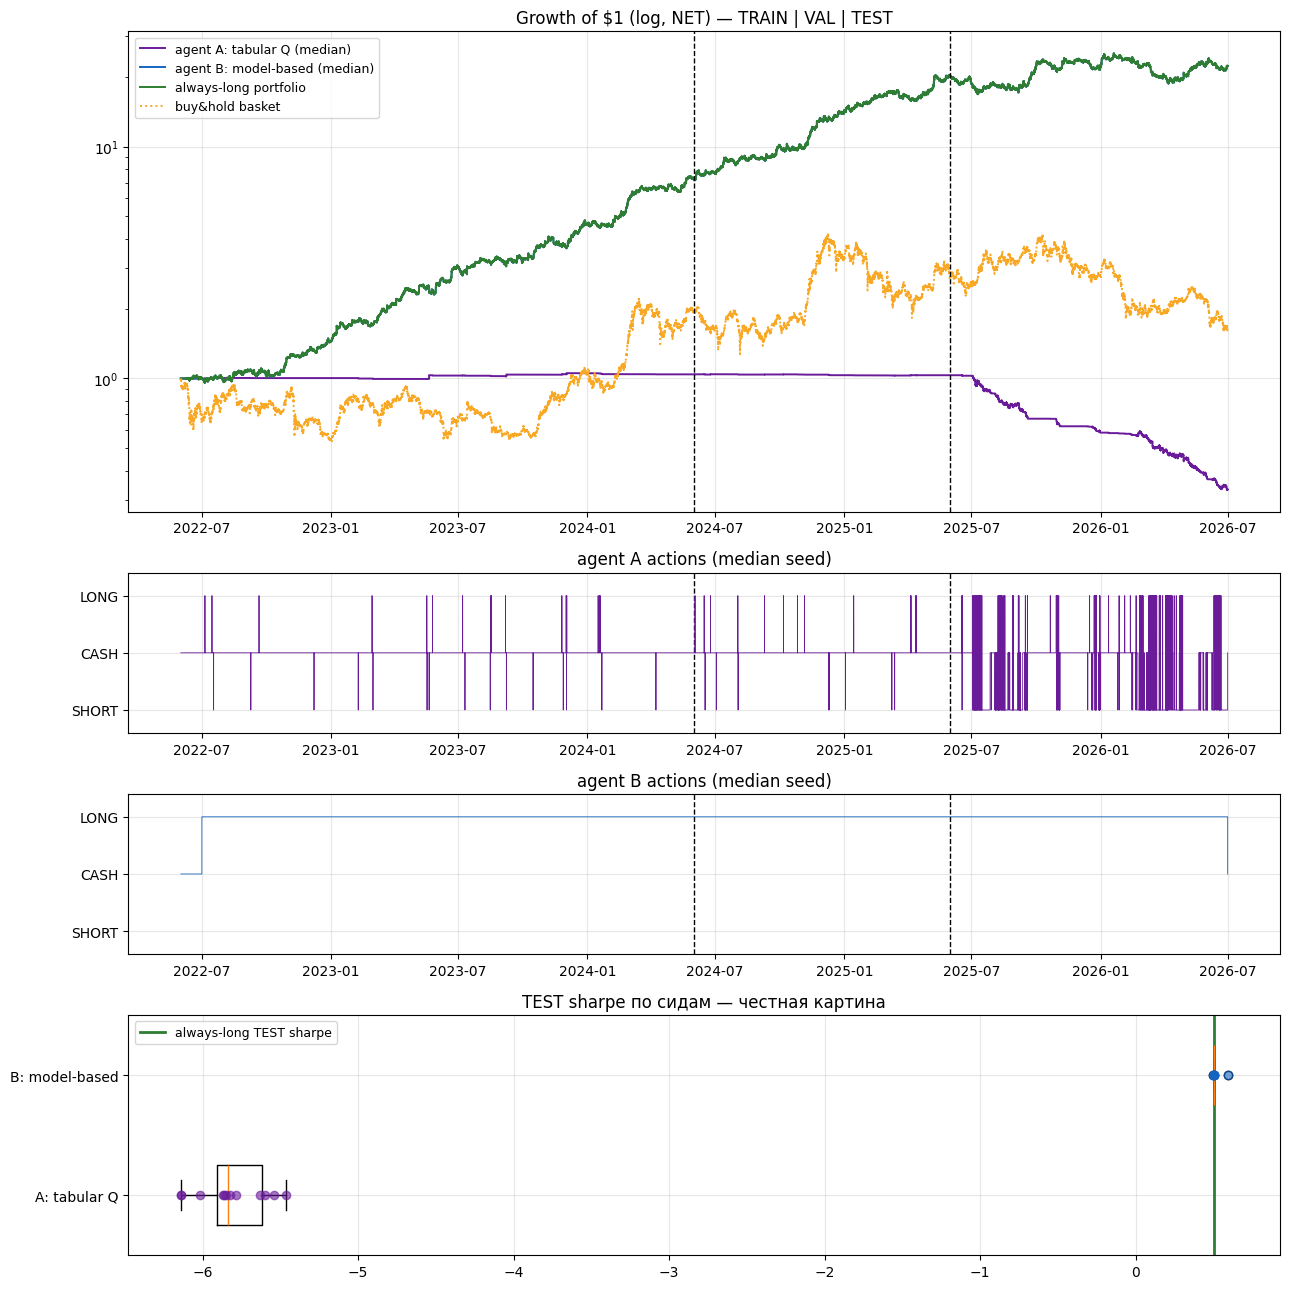

In [9]:
fig, (ax, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(13, 13),
    gridspec_kw={'height_ratios': [3, 1, 1, 1.5]})
for r, lbl, col, ls in [(med_a['rl'], 'agent A: tabular Q (median)', '#6a1b9a', '-'),
                        (med_b['rl'], 'agent B: model-based (median)', '#1565c0', '-'),
                        (p, 'always-long portfolio', '#2e7d32', '-'),
                        (bh, 'buy&hold basket', '#f9a825', ':')]:
    ax.plot(idx, (1 + r).cumprod(), lw=1.4, color=col, ls=ls, label=lbl)
ax.set_yscale('log'); ax.grid(alpha=0.3); ax.legend(loc='upper left', fontsize=9)
for x in (VA, TE):
    for a_ in (ax, ax2, ax3):
        a_.axvline(x, color='k', ls='--', lw=1)
ax.set_title('Growth of $1 (log, NET) — TRAIN | VAL | TEST')

ax2.step(idx, ACT[med_a['acts']], where='post', lw=0.6, color='#6a1b9a')
ax2.set_yticks([-1, 0, 1]); ax2.set_yticklabels(['SHORT', 'CASH', 'LONG'])
ax2.set_ylim(-1.4, 1.4); ax2.grid(alpha=0.3); ax2.set_title('agent A actions (median seed)')

ax3.step(idx, ACT[med_b['acts']], where='post', lw=0.6, color='#1565c0')
ax3.set_yticks([-1, 0, 1]); ax3.set_yticklabels(['SHORT', 'CASH', 'LONG'])
ax3.set_ylim(-1.4, 1.4); ax3.grid(alpha=0.3); ax3.set_title('agent B actions (median seed)')

ax4.boxplot([sh_a, sh_b], vert=False, widths=0.5, labels=['A: tabular Q', 'B: model-based'])
ax4.axvline(metrics(p, m_test)['sharpe'], color='#2e7d32', lw=2, label='always-long TEST sharpe')
ax4.scatter(sh_a, np.ones(len(sh_a)), alpha=0.6, color='#6a1b9a', zorder=3)
ax4.scatter(sh_b, np.full(len(sh_b), 2), alpha=0.6, color='#1565c0', zorder=3)
ax4.legend(fontsize=9); ax4.grid(alpha=0.3)
ax4.set_title('TEST sharpe по сидам — честная картина')
plt.tight_layout(); plt.show()

## 6. Как читать результат

- **Смотри на боксплоты, а не на лучший сид.** Медиана ниже зелёной линии = агент
  ценности не добавил, и в 20× больших данных дело было не в данных.
- **corr(r̂, r_next) на TEST — научное ядро эксперимента.** Если прогноз следующего
  часа не имеет OOS-корреляции с реальностью, никакая политика поверх него не спасёт:
  RL здесь математически не может знать больше, чем эта модель.
- **Издержки на 1h — главный противник.** 10 bp за переключение при часовой частоте
  съедают всё: агент, переключающийся раз в день, платит ~3.7% годовых только за
  вход-выход из лонга.
- **Бюджет подглядываний в TEST — один.** Перезапуск с другими фичами / γ / H после
  взгляда на TEST — это уже подгонка под TEST.

## Вердикт (TEST истрачен, один прогон)

1. **Агент A (табличный Q, 216 состояний): катастрофа.** Медианный TEST Sharpe **−5.84**
   (IQR −5.91..−5.62 — все 12 сидов глубоко в минусе), 493 переключения в год, 36% времени
   в шорте. Он плох даже на TRAIN (0.65) — богатое пространство состояний на часовом шуме
   не выучило ничего, а 10 bp за переключение превращают активный таймер в шредер.
2. **Агент B (model-based, 25 фич): самый честный результат эксперимента.**
   Прогноз следующего часа имеет **нулевую** OOS-корреляцию с реальностью
   (median corr(r̂, r₊₁) = −0.0025 на TEST). Издержко-зависимая политика сделала из
   этого правильный вывод: **100% лонг, 0 переключений** — агент сам схлопнулся в
   «всегда лонг» (его строка в таблице идентична бейзлайну: 0.51 / −26%). Лучшее, что
   смог выучить умный агент — не трогать портфель.
3. **«Данных больше — может что-то выйдет» — проверено: не вышло.** 26 304 обучающих
   бара против ~1200 на дневках, вывод тот же: вся предсказуемость уже извлечена
   альфами, остаточный следующий бар не прогнозируется. Проблема была не в данных.
4. **Побочное наблюдение важнее основного:** сам топ-5 портфель 1h на TEST дал лишь
   **0.51** при in-sample ~3.7–3.9 — разрыв in-sample→OOS на 1h гораздо шире, чем на
   дневках. Библиотека 1h молодая (3 раунда, 45 альф) — деплоить часовых чемпионов
   после столь короткого майнинга рано.
5. Бюджет подглядываний в TEST истрачен. Перезапуски с другими γ / H / фичами после
   этих цифр — подгонка под TEST; не делаем.